In [3]:
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import cohen_kappa_score
import seaborn as sns

In [4]:
def plot_ray(dataset, title, ax):
    ds_score = np.array([data['num'] for data in dataset if data['model'] == 'DS'])
    gpt_score = np.array([data['num'] for data in dataset if data['model'] == 'GPT'])

    labels = ['Effectiveness', 'Accuracy', 'Personalization', 'Safety', 'Emotional Care']
    ds_values = np.average(ds_score, axis=0).tolist()
    gpt_values = np.average(gpt_score, axis=0).tolist()

    for i in range(len(labels)):
        u_stat, p_mannu = stats.mannwhitneyu(ds_score.T[i], gpt_score.T[i])
        if p_mannu < 0.01:
            labels[i] += "*"

    ds_var = np.var(ds_score, axis=0).tolist()
    gpt_var = np.var(gpt_score, axis=0).tolist()

    ds_values = ds_values[1:] + ds_values[:1]
    gpt_values = gpt_values[1:] + gpt_values[:1]
    labels = labels[1:] + labels[:1]

    ds_values += ds_values[:1]
    gpt_values += gpt_values[:1]
    labels += labels[:1]

    num_vars = len(labels) - 1
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    # fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, ds_values, linewidth=1, label='DeepSeek-R1', color="#8ECFC9")
    ax.fill(angles, ds_values, alpha=0.25, color="#8ECFC9")
    # for angle, mean, variance in zip(angles, ds_values, ds_var):
    #     ax.errorbar(angle, mean, yerr=variance, color='#8ECFC9', capsize=2, capthick=2, label='DeepSeek-R1 Variance' if angle == angles[0] else "")
    for i, (angle, value) in enumerate(zip(angles, ds_values)):
        ax.text(angle, value + 0.2, f'{value:.2f}', ha='left', va='bottom', fontsize=10, color="#8ECFC9", fontweight="bold")

    ax.plot(angles, gpt_values, linewidth=1, label='GPT-o3', color="#FFBE7A")
    ax.fill(angles, gpt_values, alpha=0.25, color="#FFBE7A")
    # for angle, mean, variance in zip(angles, gpt_values, gpt_var):
    #     ax.errorbar(angle, mean, yerr=variance, color='#FFBE7A', capsize=2, capthick=2, label='GPT-o3 Variance' if angle == angles[0] else "")
    for i, (angle, value) in enumerate(zip(angles, gpt_values)):
        ax.text(angle, value + 0.2, f'{value:.2f}', ha='right', va='top', fontsize=10, color="#FFBE7A", fontweight="bold")

    ax.set_ylim(0, 4)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels[:-1])

    ax.set_title(title, va='bottom', fontsize=16)
    # ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

In [5]:
dataset_A = json.load(open("../../survey_result/dataset_A.json", 'r'))
dataset_B = json.load(open("../../survey_result/dataset_B.json", 'r'))

In [6]:
for data in dataset_A[0]:
    if data['num'][2] ==0:
        print(data['id'])

128
74
118
130


In [7]:
from scipy import stats

def cal_diff(dataset):
    labels = ['Effectiveness', 'Accuracy', 'Personalization', 'Safety', 'Emotional Care']
    ds_score = np.array([data['num'] for data in dataset if data['model'] == 'DS'])
    gpt_score = np.array([data['num'] for data in dataset if data['model'] == 'GPT'])
    for i in range(len(labels)):
        print(labels[i])
        u_stat, p_mannu = stats.mannwhitneyu(ds_score.T[i], gpt_score.T[i])
        print(f"Mann-Whitney U检验: U = {u_stat:.3f}, p = {p_mannu:.3f}")

In [8]:
cal_diff(dataset_A[0])
print()
cal_diff(dataset_A[1])
print()
cal_diff(dataset_B[0])
print()
cal_diff(dataset_B[1])
print()

Effectiveness
Mann-Whitney U检验: U = 1022.000, p = 0.007
Accuracy
Mann-Whitney U检验: U = 1473.000, p = 0.100
Personalization
Mann-Whitney U检验: U = 1738.000, p = 0.000
Safety
Mann-Whitney U检验: U = 1403.000, p = 0.273
Emotional Care
Mann-Whitney U检验: U = 1377.500, p = 0.323

Effectiveness
Mann-Whitney U检验: U = 1277.500, p = 0.750
Accuracy
Mann-Whitney U检验: U = 1352.000, p = 0.400
Personalization
Mann-Whitney U检验: U = 1339.500, p = 0.514
Safety
Mann-Whitney U检验: U = 1131.500, p = 0.333
Emotional Care
Mann-Whitney U检验: U = 1007.500, p = 0.051

Effectiveness
Mann-Whitney U检验: U = 1827.000, p = 0.000
Accuracy
Mann-Whitney U检验: U = 1872.500, p = 0.000
Personalization
Mann-Whitney U检验: U = 1924.000, p = 0.000
Safety
Mann-Whitney U检验: U = 1217.000, p = 0.799
Emotional Care
Mann-Whitney U检验: U = 2080.000, p = 0.000

Effectiveness
Mann-Whitney U检验: U = 1175.000, p = 0.494
Accuracy
Mann-Whitney U检验: U = 1522.000, p = 0.032
Personalization
Mann-Whitney U检验: U = 1392.000, p = 0.260
Safety
Mann-Whitney

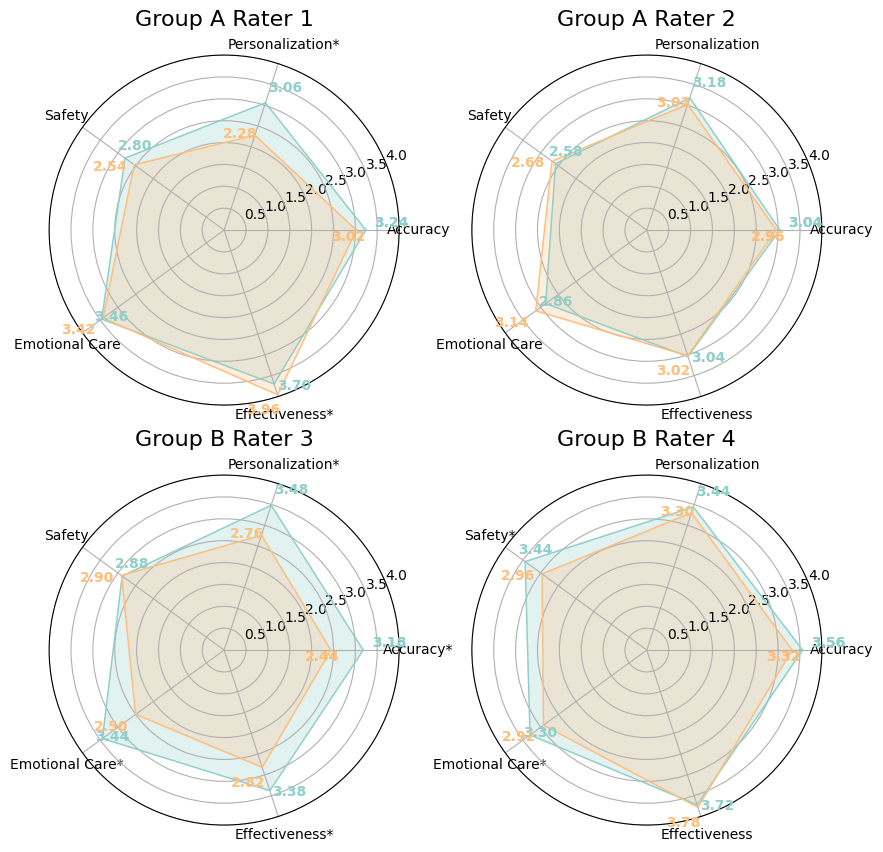

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), subplot_kw=dict(polar=True))
plot_ray(dataset_A[0], "Group A Rater 1", axes[0][0])
plot_ray(dataset_A[1], "Group A Rater 2", axes[0][1])
plot_ray(dataset_B[0], "Group B Rater 3", axes[1][0])
plot_ray(dataset_B[1], "Group B Rater 4", axes[1][1])
plt.show()